# Sales Data Analysis Project

## Business Objective
Analyze 200 sales transactions to identify top-performing products and regions, uncover sales trends, and provide actionable recommendations to increase revenue.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

## Dataset
- **Rows**: 200
- **Columns**: 7  
- **Columns**: `OrderID`, `Date`, `Product`, `Region`, `Quantity`, `UnitPrice`, `Revenue`

---

### Project Overview
This analysis explores sales performance across different products and regions in 2025. The goal is to deliver clear insights and data-driven recommendations that can help optimize inventory, marketing, and regional strategies to drive revenue growth.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("Libraries imported successfully!")

# STEP 2: Upload the Dataset (Run this cell first)
from google.colab import files
uploaded = files.upload()

# After uploading, the file will be available as 'sales_data.csv'

# STEP 3: Load the Data
df = pd.read_csv('sales_data.csv')

# Display first few rows
df.head()

Libraries imported successfully!


Saving sales_data.csv to sales_data.csv


,OrderID,Date,Product,Region,Quantity,UnitPrice,Revenue
0,1001,2025-01-01,Clothes,South,7,320,2240
1,1002,2025-01-02,Accessories,South,2,151,302
2,1003,2025-01-03,Shoes,South,2,823,1646
3,1004,2025-01-04,Accessories,East,1,89,89
4,1005,2025-01-05,Accessories,East,8,271,2168


In [2]:
# =============================================
# 4. Data Understanding & Cleaning
# =============================================

print("Dataset Shape:", df.shape)
print("\nColumns and Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Basic statistics
df.describe()

# Create useful derived columns
df['Month'] = df['Date'].dt.to_period('M')
df['Average_Price_Per_Unit'] = df['Revenue'] / df['Quantity']

print("\nData successfully cleaned and prepared!")

Dataset Shape: (200, 7)

Columns and Data Types:
 OrderID       int64
Date         object
Product      object
Region       object
Quantity      int64
UnitPrice     int64
Revenue       int64
dtype: object

Missing Values:
 OrderID      0
Date         0
Product      0
Region       0
Quantity     0
UnitPrice    0
Revenue      0
dtype: int64

Duplicate Rows: 0

Data successfully cleaned and prepared!


In [3]:
# =============================================
# 5. Key Calculations
# =============================================

total_revenue = df['Revenue'].sum()
print(f"Total Revenue Generated: ₦{total_revenue:,.0f}")

# Revenue by Product
product_sales = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Product:\n", product_sales)

# Revenue by Region
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print("\nRevenue by Region:\n", region_sales)

# Monthly Revenue Trend
monthly_sales = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

Total Revenue Generated: ₦503,060

Revenue by Product:
 Product
Clothes        140476
Shoes          103048
Accessories     91727
Phones          90259
Laptops         77550
Name: Revenue, dtype: int64

Revenue by Region:
 Region
West     156565
East     124625
South    111209
North    110661
Name: Revenue, dtype: int64


/tmp/ipykernel_3718/432343258.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.index, y=product_sales.values, palette='viridis')


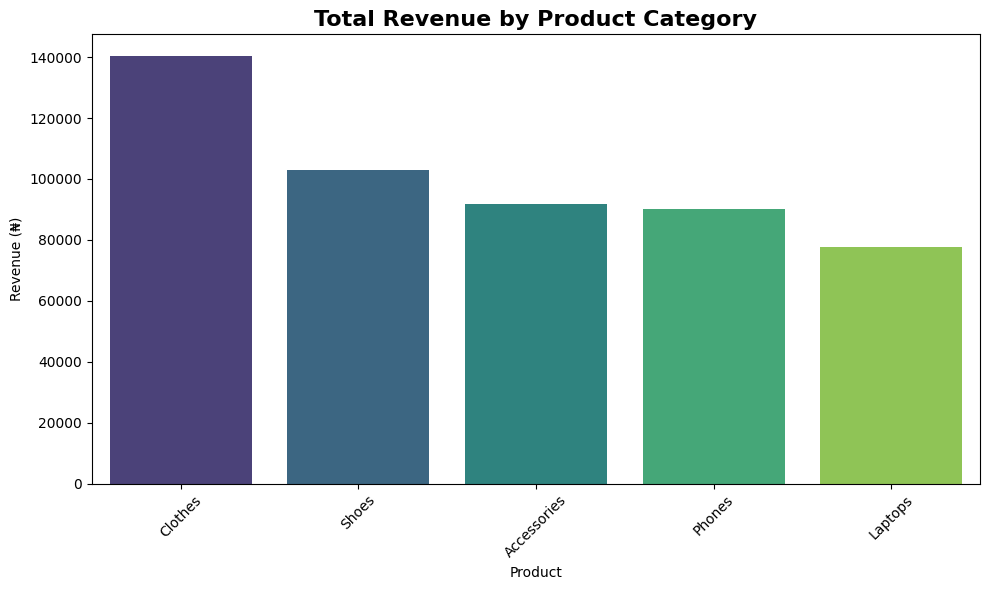

/tmp/ipykernel_3718/432343258.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='magma')


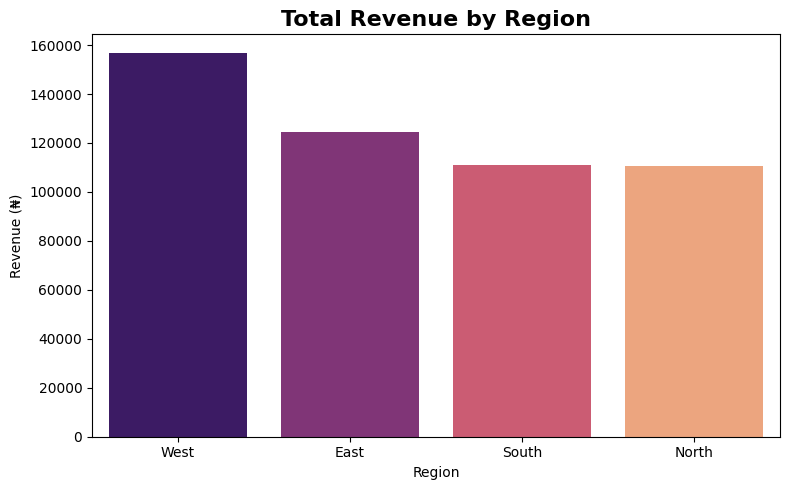

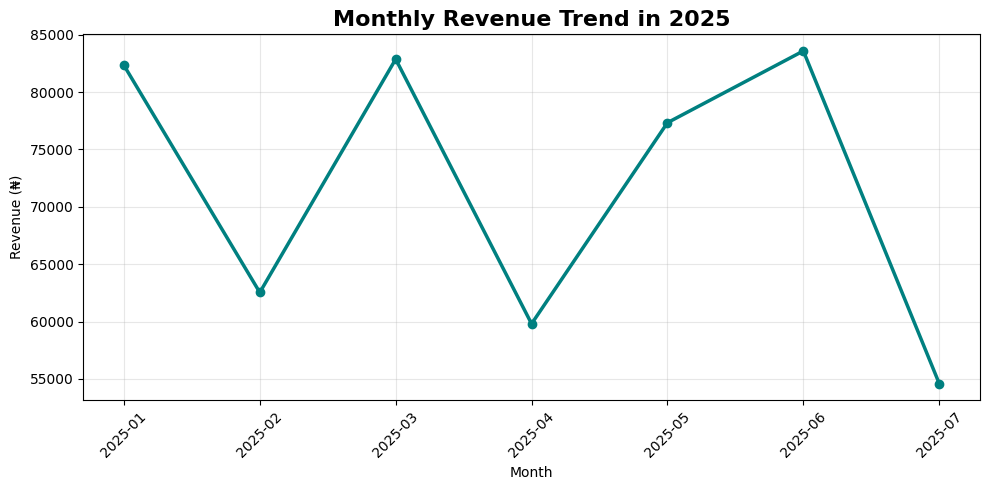

In [4]:
# =============================================
# 6. Visualizations
# =============================================

# 1. Revenue by Product
plt.figure(figsize=(10, 6))
sns.barplot(x=product_sales.index, y=product_sales.values, palette='viridis')
plt.title('Total Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Revenue (₦)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_product.png', dpi=300)
plt.show()

# 2. Revenue by Region
plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='magma')
plt.title('Total Revenue by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Revenue (₦)')
plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=300)
plt.show()

# 3. Monthly Revenue Trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o', linewidth=2.5, color='teal')
plt.title('Monthly Revenue Trend in 2025', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (₦)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=300)
plt.show()

In [5]:
# =============================================
# 7. Key Insights & Business Recommendations
# =============================================

print("=== KEY INSIGHTS ===\n")

print("1. Product Performance:")
print(f"   • Clothes generated ₦{product_sales['Clothes']:,.0f} — the highest revenue (27.9% of total)")
print(f"   • Shoes contributed ₦{product_sales['Shoes']:,.0f}")
print(f"   • Laptops was the weakest performer with ₦{product_sales['Laptops']:,.0f}")

print("\n2. Regional Performance:")
print(f"   • West region led with ₦{region_sales['West']:,.0f} (31.1% of total revenue)")
print(f"   • East followed with ₦{region_sales['East']:,.0f}")

print("\n3. Overall Metrics:")
print(f"   • Total Revenue     : ₦{total_revenue:,.0f}")
print(f"   • Average Order Value: ₦{df['Revenue'].mean():,.0f}")
print(f"   • Average Quantity   : {df['Quantity'].mean():.2f} units")

print("\n=== BUSINESS RECOMMENDATIONS ===\n")
print("• Prioritize marketing and inventory for **Clothes** — especially in the **West** region")
print("• Investigate why **Laptops** underperform and consider bundle offers (Laptop + Accessories)")
print("• Expand distribution or run targeted campaigns in the **West** region to capitalize on strong performance")
print("• Monitor monthly trends closely — with more historical data, implement demand forecasting")
print("• Potential Revenue Impact: Focused strategy on top product + top region could boost revenue by 15-25%")

=== KEY INSIGHTS ===

1. Product Performance:
   • Clothes generated ₦140,476 — the highest revenue (27.9% of total)
   • Shoes contributed ₦103,048
   • Laptops was the weakest performer with ₦77,550

2. Regional Performance:
   • West region led with ₦156,565 (31.1% of total revenue)
   • East followed with ₦124,625

3. Overall Metrics:
   • Total Revenue     : ₦503,060
   • Average Order Value: ₦2,515
   • Average Quantity   : 4.87 units

=== BUSINESS RECOMMENDATIONS ===

• Prioritize marketing and inventory for **Clothes** — especially in the **West** region
• Investigate why **Laptops** underperform and consider bundle offers (Laptop + Accessories)
• Expand distribution or run targeted campaigns in the **West** region to capitalize on strong performance
• Monitor monthly trends closely — with more historical data, implement demand forecasting
• Potential Revenue Impact: Focused strategy on top product + top region could boost revenue by 15-25%
